# Aprendizaje no supervisado

## Creación del dataset

Se creo un dataset bidimensional cuyos datos se generan a partir de un *manifold unidimensional* perturbado por ruido gaussiano.
Un manifold se refiere al espacio efectivo de menor dimensión en el que habitan los datos.

El manifold se define mediante una función paramétrica $g[0,1]→\mathbb{R}^2$ que mapea un parámetro unidimensional $u$ a puntos en el plano. La función esta definida por tramos, creando una curva de 4 segmentos. Esta elección de diferentes direcciones de segmentos, aunque es continua, permite evaluar la capacidad del algoritmo ante distintas regiones del espacio.

El dataset final se construye mediante un modelo generativo probabilistico que combina manifold deterministico con ruido estocástico gaussiano.Se muestrea el parámetro latente $U$ que tiene una distribución uniforme, este determina la posición del punto sobre el manifold verdadero, se calcula $g(U_i)$ y luego se adiciona el ruido dado a $Z$ siendo un vector aleatorio bidimensional con distribución normal estándar multivariada con un factor de escala de $0.05$ que controla la relación señal-ruido del dataset, esto garantiza que el ruido no distorsione excesivamente la estructura del manifold, también se define como la desviación estándar del ruido. El dato final se define como:
$$X_i = g(U_i) + 0.05⋅Z_i $$

## Gráficos

En el primer gráfico es un scatter plot de las muestras $X_i$, donde podemos ver una cierta linealidad con respecto al manifold subyacente y la introducción del ruido, que desplazo ligeramente los puntos de su posición exacta pero sin destruir la estructura fundamental, el cual en conjunto lo vemos en el gráfico dos donde esta superpuesto este primer gráfico con el manifold verdadero (sin ruido). Podemos concluir que la magnitud del ruido es suficientemente pequeña para que la estructura sea visualmente clara.


In [1]:
import matplotlib.pyplot as plt
import numpy as np

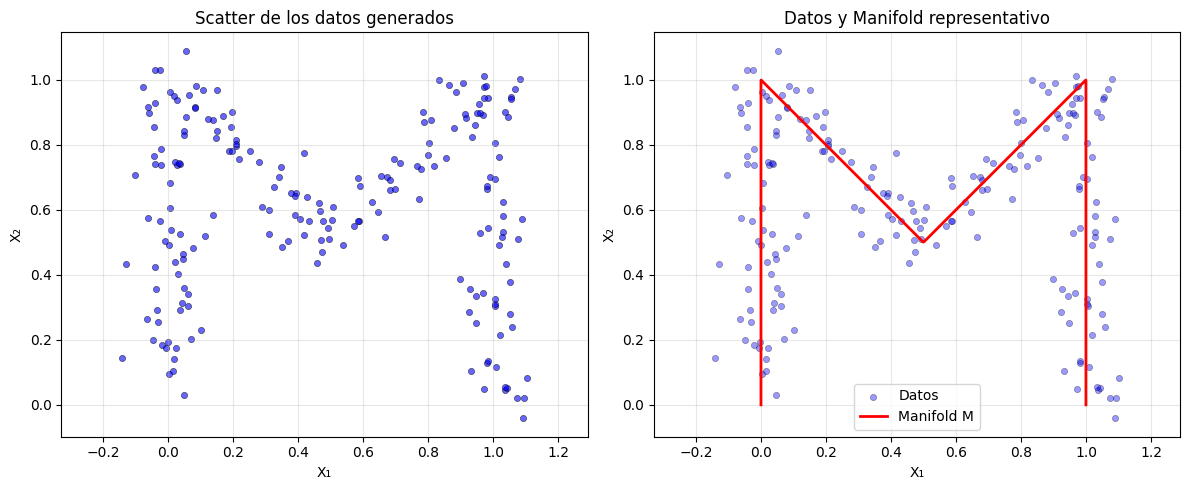

In [2]:
def g(u): #Función que define el manifold

    # Convertir u a array
    u = np.atleast_1d(u)
    n = len(u)

    # Inicializar el resultado
    result = np.zeros((n, 2))

    # Caso 1: 0 <= u < 0.25
    mask1 = (u >= 0) & (u < 0.25)
    result[mask1, 0] = 0
    result[mask1, 1] = 4 * u[mask1]

    # Caso 2: 0.25 <= u < 0.5
    mask2 = (u >= 0.25) & (u < 0.5)
    result[mask2, 0] = 2 * u[mask2] - 0.5
    result[mask2, 1] = 1.5 - 2 * u[mask2]

    # Caso 3: 0.5 <= u < 0.75
    mask3 = (u >= 0.5) & (u < 0.75)
    result[mask3, 0] = 2 * u[mask3] - 0.5
    result[mask3, 1] = 2 * u[mask3] - 0.5

    # Caso 4: 0.75 <= u <= 1
    mask4 = (u >= 0.75) & (u <= 1)
    result[mask4, 0] = 1
    result[mask4, 1] = 4 - 4 * u[mask4]

    return result

# 1. Generar el conjunto de datos
n = 200

# Generar Ui ~ U(0, 1) i.i.d.
U = np.random.uniform(0, 1, n)

# Generar Zi ~ N(0, I_2) i.i.d. (normal estándar bivariada)
Z = np.random.randn(n, 2)

# Generar Xi = g(Ui) + 0.05 * Zi
X = g(U) + 0.05 * Z

# 2. Graficar scatter de los datos
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(X[:, 0], X[:, 1], alpha=0.6, s=20, c='blue', edgecolors='k', linewidth=0.5)
plt.xlabel('X₁')
plt.ylabel('X₂')
plt.title('Scatter de los datos generados')
plt.grid(True, alpha=0.3)
plt.axis('equal')

# 3. Graficar la curva representativa del manifold
# Generar puntos densos en el manifold
u_manifold = np.linspace(0, 1, 1000)
manifold_points = g(u_manifold)

plt.subplot(1, 2, 2)
plt.scatter(X[:, 0], X[:, 1], alpha=0.4, s=20, c='blue', edgecolors='k', linewidth=0.5, label='Datos')
plt.plot(manifold_points[:, 0], manifold_points[:, 1], 'r-', linewidth=2, label='Manifold M')
plt.xlabel('X₁')
plt.ylabel('X₂')
plt.title('Datos y Manifold representativo')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.tight_layout()
plt.show()




## PCA condicional
El **PCA condicional** es una técnica de aprendizaje no supervisado diseñada para modelar manifolds de baja dimensionalidad que no pueden ser descritos adecuadamente mediante un único modelo lineal.
La estrategia del PCA condicional aborda este problema mediante una aproximación de dos etapas. Primero, se particiona el espacio de datos en regiones localmente homogéneas mediante un algoritmo de clustering, identificando subconjuntos de puntos que comparten características geométricas similares. Segundo, se aplica PCA de manera independiente en cada cluster, permitiendo que cada región tenga su propia dirección principal óptima. Esta metodología se denomina "condicional" porque la proyección PCA que se aplica a un punto está condicionada a su pertenencia a un cluster específico: dependiendo del cluster al que el punto sea asignado, se utilizará una base de proyección diferente.

## K-Means

Usamos como herramienta de clustering al algoritmo de **K-Means**. Este es un algoritmo que busca dividir un conjunto de *n* observaciones en K clusters disjuntos, minimizando la suma de las distancias cuadradas de cada punto a su centroide asignado, en definitiva lo que hace es resolver el problema de optimización:
$$ min_{{\{\mu_k\}}_{k=1}^K, \{C_k\}^K_{k=1}}\sum_{k=1}^K \sum_{x_i∈ C_k} ||x_i -μ_k||^2 $$

donde $C_k$ representa el conjunto de puntos asignados al cluster k y $\mu_k$ es el centroide de los puntos en $C_k$. El algoritmo alterna entre *Expectation* donde cada punto se asigna al centroide más cercano según la distancia euclidiana, y *Maximization* donde los centroides se recalculan como el promedio artimético de los puntos asignados a cada cluster.

In [3]:
class KMeans:
    #Hiperparámetros
    def __init__(self, K, max_iters=100, tol=1e-4):

        self.K = K #Número de clusters
        self.max_iters = max_iters #Límite de iteracio nes para evitar bucles inf
        self.tol = tol #Tolerancia para determinar convergencia
        self.centroids = None #Se almacena las posiciones finales de los K centroides
        self.labels_ = None #Asignaciones de cluster para cada punto del conj de entrenamiento

    #Función de entrenamiento
    def fit(self, X):

        n_samples, d = X.shape

        # Inicializar centroides seleccionando K puntos aleatorios
        random_indices = np.random.choice(n_samples, self.K, replace=False)
        self.centroids = X[random_indices].copy()

        # Iterar hasta convergencia o número máximo de iteraciones
        for iteration in range(self.max_iters):
            # E-step: Calcula la distancia euclidianas a todos los centroides
            # y asigna el punto al cluster con dist minima
            # distance = ||x_i - mu_k||
            labels = np.zeros(n_samples, dtype=int)
            for i in range(n_samples):
                distances = np.zeros(self.K)
                for k in range(self.K):
                    distances[k] = np.linalg.norm(X[i] - self.centroids[k])
                labels[i] = np.argmin(distances)

            # M-step: Recalcula cada centroide como la media aritmetica de sus puntos asignados
            # mu_ k = 1/|C_k| \sum x_i
            new_centroids = np.zeros((self.K, d))
            for k in range(self.K):
                cluster_points = X[labels == k]
                new_centroids[k] = np.mean(cluster_points, axis=0)
             # Verificar convergencia
            if np.linalg.norm(new_centroids - self.centroids) < self.tol:
                break

            self.centroids = new_centroids

        self.labels_ = labels
        return self

#Predicción: permite clasificar nuevos puntos no vistos durante el entrenamiento
    def predict(self, X):
        n_samples = X.shape[0]
        labels = np.zeros(n_samples, dtype=int)

        for i in range(n_samples):
            distances = np.zeros(self.K)
            for k in range(self.K):
                distances[k] = np.linalg.norm(X[i] - self.centroids[k])
            labels[i] = np.argmin(distances)

        return labels


### Graficar scatter con colores distintos por cluster
Con K = 4 clusters, K-Means identifica las cuatro regiones del dataset correspondientes a los cuatro segmentos de la función *g(u)*. Esto lo podemos ver en el gráfico el cual detalla claramente cada cluster de una forma eficiente.

K-Means identifica las regiones homogeneas y asigna cada punto a un cluster, esto como vemos lo hace perfectamente, pero K-Means es un algoritmo de clustering que no extrae información sobre la estructura geométrica local requerida para la proyección y reconstrucción sobre el manifold, mas allá de la posición central de cada grupo, por lo que no se considera suficiente para implementar PCA condicional, dado que falta la dirección principal del cluster.

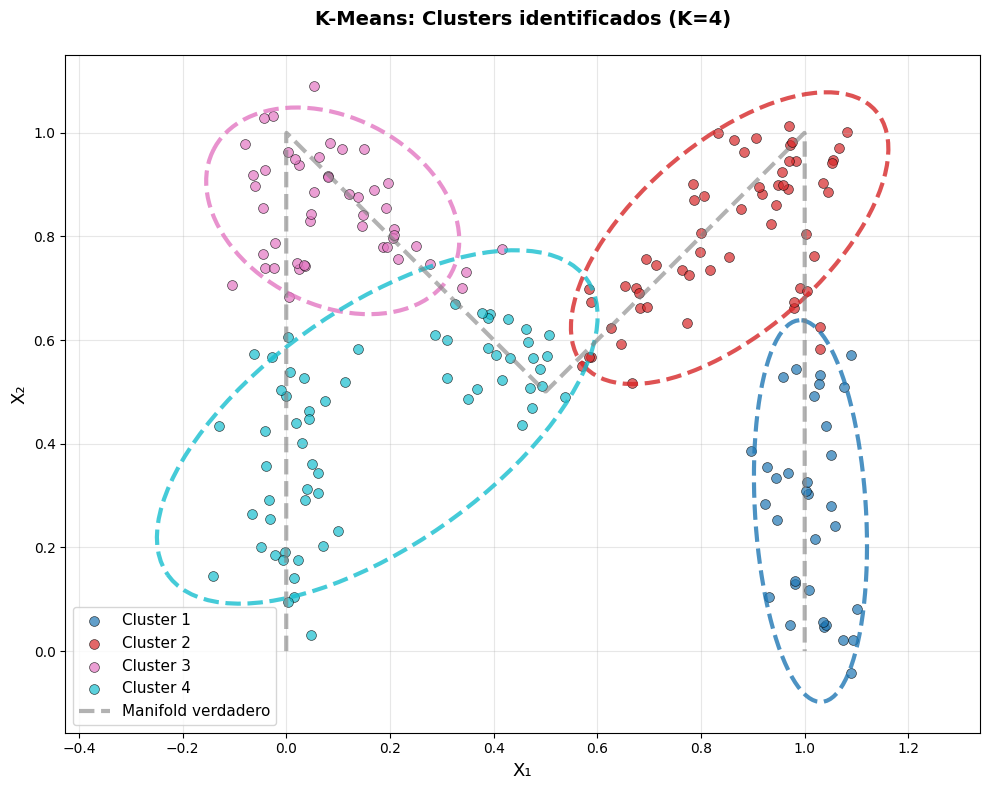

In [4]:
#Entrenar K-Means
K = 4
kmeans = KMeans(K=K, max_iters=100)
kmeans.fit(X)

fig, ax = plt.subplots(1, 1, figsize=(10, 8))

# Colores para cada cluster
colors = plt.cm.tab10(np.linspace(0, 1, K))

# Graficar cada cluster con un color diferente
for k in range(K):
    cluster_points = X[kmeans.labels_ == k]
    ax.scatter(cluster_points[:, 0], cluster_points[:, 1],
              c=[colors[k]], s=50, alpha=0.7,
              edgecolors='k', linewidth=0.5,
              label=f'Cluster {k+1}')

#Graficar centroides
for k in range(K):
    cluster_points = X[kmeans.labels_ == k]

    if len(cluster_points) > 1:
        # Calcular matriz de covarianza
        cov = np.cov(cluster_points.T)

        # Calcular autovalores y autovectores
        eigenvalues, eigenvectors = np.linalg.eigh(cov)

        # Ordenar de mayor a menor
        idx = eigenvalues.argsort()[::-1]
        eigenvalues = eigenvalues[idx]
        eigenvectors = eigenvectors[:, idx]

        # Generar puntos de una elipse (círculo unitario parametrizado)
        theta = np.linspace(0, 2 * np.pi, 100)
        circle = np.array([np.cos(theta), np.sin(theta)])

        # Escalar por las desviaciones estándar (2 sigma)
        ellipse = np.sqrt(eigenvalues[:, np.newaxis]) * 2 * circle

        # Rotar usando los autovectores
        ellipse_rotated = eigenvectors @ ellipse

        # Trasladar al centroide
        ellipse_final = ellipse_rotated + kmeans.centroids[k][:, np.newaxis]

        # Graficar la elipse
        ax.plot(ellipse_final[0, :], ellipse_final[1, :],
               color=colors[k], linewidth=3, linestyle='--', alpha=0.8)

# Graficar manifold verdadero
ax.plot(manifold_points[:, 0], manifold_points[:, 1],
       'gray', linewidth=3, alpha=0.6, linestyle='--',
       label='Manifold verdadero')

ax.set_xlabel('X₁', fontsize=13)
ax.set_ylabel('X₂', fontsize=13)
ax.set_title(f'K-Means: Clusters identificados (K={K})\n',
            fontsize=14, fontweight='bold')
ax.legend(loc='best', fontsize=11)
ax.grid(True, alpha=0.3)
ax.axis('equal')

plt.tight_layout()
plt.show()

## Algoritmo EM

El algoritmo de Expectation-Maximization es una herramienta iterativa para encontrar estimaciones de máxima verosimilitud de los parámetros de modelos estadísticos, particularmente cuando el modelo depende de variables no observadas (latentes).
El modelo matematico que utiliza EM es **GMM** (*Gaussian Mixture Model*)
El objetivo de EM es encontrar los valores de   $\theta = \{c_k, \mu_k, \Sigma_k\}_{k=1}^K$  que mejor expliquen los datos que observamos. En términos técnicos, queremos **maximizar la verosimilitud**: encontrar los parámetros que hacen que nuestros datos observados sean ''lo más probables posible'' bajo el modelo.
Matemáticamente, esto se expresa como maximizar la log-verosimilitud:
$$
\mathcal{L}(\theta) = \sum_{i=1}^n \log p(x_i | \theta)
$$
que mide qué tan bien el modelo con parámetros $\theta$ explica cada punto
$x_i$.

El algoritmo iterativo EM, resuelve el problema de manera indirecta, en lugar de  intentar resolver todo de una vez, alterna entre dos pasos más simples. En el **paso E (Expectation)**, dados los parámetros actuales, calculamos para
cada punto cuál es la probabilidad de que pertenezca a cada cluster (las
''responsabilidades''). En el **paso M (Maximization)**, usando esas
probabilidades calculadas, actualizamos los parámetros del modelo para que se
ajusten mejor a los datos. Repetimos estos dos pasos una y otra vez hasta que
los parámetros dejan de cambiar significativamente, lo que indica que hemos
encontrado una buena solución. Es como un proceso de ''adivinar y mejorar'':
comenzamos con una estimación inicial ( proporcionada por K-Means),
calculamos qué tan bien explica los datos, ajustamos los parámetros para mejorar
la explicación, y repetimos hasta que no podemos mejorar más. Aunque no garantiza
encontrar la mejor solución posible global (puede quedarse en un ''óptimo
local'').


In [5]:
class EM:
  #Inicialización de parámetros
    def __init__(self, K, max_iters=100, tol=1e-4):

        self.K = K
        self.max_iters = max_iters
        self.tol = tol

        # Parámetros del modelo
        self.c = None #Prob. a priori
        self.mu = None
        self.Sigma = None
        self.labels_ = None

#Etapa de entrenamiento
    def fit(self, X):

        n, d = X.shape
        # Se aprovecha la capacidad de K-means para identificar estructuras de clustering
        kmeans = KMeans(K=self.K, max_iters=self.max_iters)
        kmeans.fit(X)
        labels_init = kmeans.labels_

        self.mu = np.zeros((self.K, d))
        self.Sigma = np.zeros((self.K, d, d))
        self.c = np.zeros(self.K)

        for k in range(self.K):
            cluster_points = X[labels_init == k]
            n_k = len(cluster_points)

            self.c[k] = n_k / n #prob a priori c_k = |C_k| / n
            self.mu[k] = np.mean(cluster_points, axis=0) #Media inicial
            centered = cluster_points - self.mu[k]
            self.Sigma[k] = (centered.T @ centered) / n_k

        prev_log_likelihood = -np.inf

        for iteration in range(self.max_iters):
            responsibilities = np.zeros((n, self.K))

            for k in range(self.K):
                #E-Step
                # Calcular gaussiana multivariada
                det_Sigma = np.linalg.det(self.Sigma[k])
                inv_Sigma = np.linalg.inv(self.Sigma[k])
                norm_const = 1.0 / (np.sqrt((2 * np.pi)**d * det_Sigma))

                x_centered = X - self.mu[k]
                exponent = -0.5 * np.sum(x_centered @ inv_Sigma * x_centered, axis=1)
                responsibilities[:, k] = self.c[k] * norm_const * np.exp(exponent)

            # Normalizar responsabilidades
            total_prob = np.sum(responsibilities, axis=1, keepdims=True)
            responsibilities = responsibilities / total_prob

            #M-step
            N_k = np.sum(responsibilities, axis=0)

            for k in range(self.K):
                # Actualizar c_k
                self.c[k] = N_k[k] / n
                # Actualizar μ_k
                self.mu[k] = np.sum(responsibilities[:, k:k+1] * X, axis=0) / N_k[k]
                # Actualizar Σ_k
                x_centered = X - self.mu[k]
                weighted_cov = (responsibilities[:, k:k+1] * x_centered).T @ x_centered
                self.Sigma[k] = weighted_cov / N_k[k]

         # Verificar convergencia
            log_likelihood = 0.0
            for i in range(n):
                prob_sum = 0.0
                for k in range(self.K):
                    det_Sigma = np.linalg.det(self.Sigma[k])
                    inv_Sigma = np.linalg.inv(self.Sigma[k])
                    norm_const = 1.0 / np.sqrt((2 * np.pi)**d * det_Sigma)

                    x_centered = X[i] - self.mu[k]
                    exponent = -0.5 * (x_centered @ inv_Sigma @ x_centered)
                    prob_sum += self.c[k] * norm_const * np.exp(exponent)

                log_likelihood += np.log(max(prob_sum, 1e-10))

            if abs(log_likelihood - prev_log_likelihood) < self.tol:
                break

            prev_log_likelihood = log_likelihood
        # Guardar etiquetas finales
        self.labels_ = np.argmax(responsibilities, axis=1)

        return self
    #Etapa de testeo soft
    def predict_proba(self, X):
        n, d = X.shape
        responsibilities = np.zeros((n, self.K))

        # Calcular responsabilidades para cada cluster
        for k in range(self.K):
            det_Sigma = np.linalg.det(self.Sigma[k])
            inv_Sigma = np.linalg.inv(self.Sigma[k])
            norm_const = 1.0 / (np.sqrt((2 * np.pi)**d * det_Sigma))

            x_centered = X - self.mu[k]
            exponent = -0.5 * np.sum(x_centered @ inv_Sigma * x_centered, axis=1)
            responsibilities[:, k] = self.c[k] * norm_const * np.exp(exponent)

        # Normalizar
        total_prob = np.sum(responsibilities, axis=1, keepdims=True)
        responsibilities = responsibilities / total_prob
        return responsibilities

    #Etapa de testeo hard
    def predict(self, X):
        probabilities = self.predict_proba(X)
        return np.argmax(probabilities, axis=1)


### Gráfico

La imagen proporcionada muestra las fronteras de decisión resultantes de un proceso de **hard clustering** utilizando el algoritmo de Expectation-Maximization (EM). En este gráfico de dispersión, los ejes $X_1$ y $X_2$ representan las dos características o dimensiones de los datos. Se observan varios grupos de puntos de datos, coloreados de manera diferente, cada uno representando un clúster identificado por el algoritmo. Las áreas sombreadas en el fondo,  definen las "fronteras de decisión", indican la región del espacio de características asignada a cada clúster.

 La naturaleza "hard clustering" significa que cada punto de dato se asigna de forma exclusiva a uno de los clústeres. Destaca la capacidad del algoritmo EM para identificar clústeres de formas no esféricas y variadas densidades.



(np.float64(-0.3421706359311181),
 np.float64(1.3017127764322147),
 np.float64(-0.2415491020734417),
 np.float64(1.2896860950141713))

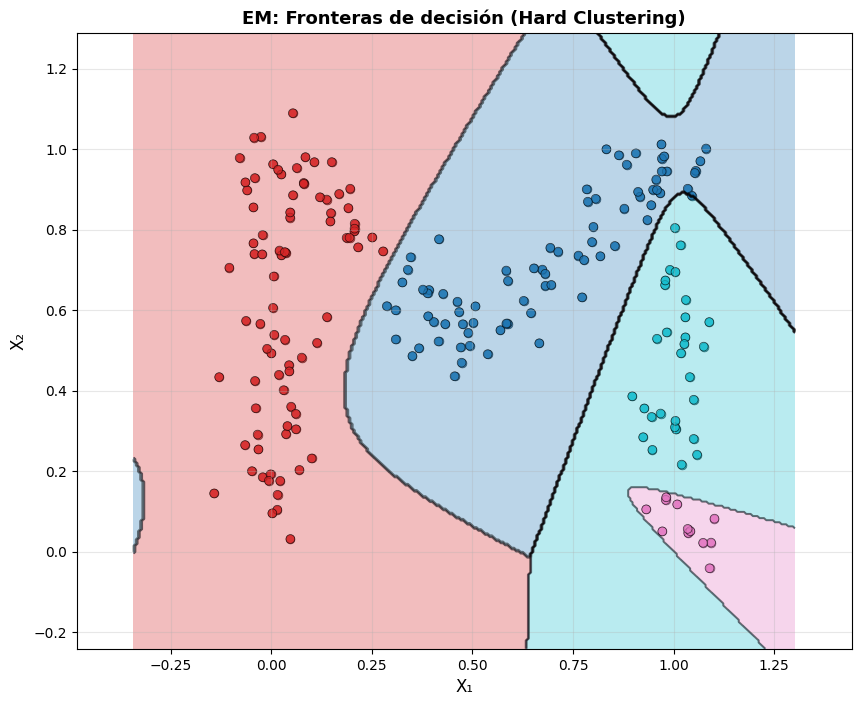

In [6]:

#Entrenar
em = EM(K=K, max_iters=100, tol=1e-6)
em.fit(X)

#Graficar scatter con clusters

fig, ax = plt.subplots(1, 1, figsize=(10, 8))
colors = plt.cm.tab10(np.linspace(0, 1, K))

for k in range(K):
    cluster_points = X[em.labels_ == k]
    ax.scatter(cluster_points[:, 0], cluster_points[:, 1],
              c=[colors[k]], s=40, alpha=0.7,
              edgecolors='k', linewidth=0.5,
              label=f'Cluster {k+1}')

# Crear malla para las fronteras de decisión
x_min, x_max = X[:, 0].min() - 0.2, X[:, 0].max() + 0.2
y_min, y_max = X[:, 1].min() - 0.2, X[:, 1].max() + 0.2
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                     np.linspace(y_min, y_max, 300))
grid_points = np.c_[xx.ravel(), yy.ravel()]


# Predecir etiquetas para cada punto de la malla
Z_labels = em.predict(grid_points)
Z_labels = Z_labels.reshape(xx.shape)

# Graficar regiones con contourf
ax.contourf(xx, yy, Z_labels, alpha=0.3, levels=K-1, colors=colors)

# Graficar fronteras con contour
ax.contour(xx, yy, Z_labels, levels=K-1, colors='black',
          linewidths=1.5, linestyles='solid', alpha=0.5)

# Graficar puntos
ax.scatter(X[:, 0], X[:, 1], c=em.labels_, cmap='tab10',
          s=40, alpha=0.7, edgecolors='k', linewidth=0.5)

ax.set_xlabel('X₁', fontsize=12)
ax.set_ylabel('X₂', fontsize=12)
ax.set_title('EM: Fronteras de decisión (Hard Clustering)',
            fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.axis('equal')



## PCA

El **Análisis de Componentes Principales** (PCA) es una técnica de reducción de dimensionalidad utilizada para transformar un conjunto de variables posiblemente correlacionadas en un conjunto de variables linealmente no correlacionadas llamadas *componentes principales*. El objetivo principal de PCA es retener la mayor cantidad de varianza posible de los datos originales en un número menor de dimensiones.

El proceso de PCA se puede resumir en los siguientes pasos:

*   **Centrado de los datos:** Se resta la media de cada característica de los datos originales. Esto asegura que la primera componente principal pase por el centro de los datos
*   **Cálculo de la matriz de covarianza:** Esta matriz cuadrada simétrica captura la relación lineal entre cada par de características.

*   **Descomposición en autovalores y autovectores:** Los autovalores y autovectores de la matriz de covarianza son calculados. Los autovectores representan las direcciones (componentes principales) a lo largo de las cuales la varianza de los datos es máxima, mientras que los autovalores asociados cuantifican la cantidad de varianza capturada a lo largo de esas direcciones.
*    **Selección de componentes principales:**  Los autovectores se ordenan en función de sus autovalores asociados de mayor a menor. Los primeros $k$ autovectores (donde $k$ es la dimensionalidad deseada del espacio latente) son seleccionados como las componentes principales, ya que capturan la mayor parte de la varianza.
*   **Proyección:** Los datos originales centrados se proyectan sobre el subespacio definido por las $k$ componentes principales seleccionadas para obtener una representación de menor dimensionalidad.



In [7]:
class PCA:

  #Etapa de inicialización
    def __init__(self, center=True):
        self.center = center #Determina si los datos deben ser centrados
        # Atributos esenciales
        self.mean_ = None
        self.components_ = None

  #Etapa de entrenamiento
    def fit(self, X):
        n, d = X.shape
        # Calcular y guardar la media
        if self.center:
            self.mean_ = np.mean(X, axis=0) #Media de cada feature
            X_centered = X - self.mean_ #Centrado
        else:
            self.mean_ = np.zeros(d)
            X_centered = X

        # Calcular la matriz de covarianza
        cov_matrix = (X_centered.T @ X_centered) / n
        # Calcular autovalores y autovectores
        eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
        # Ordenar de mayor a menor autovalor
        idx = eigenvalues.argsort()[::-1]
        eigenvectors = eigenvectors[:, idx]
        # Guardar componentes principales (cada fila es una componente)
        self.components_ = eigenvectors.T
        return self

    def transform(self, X, k):
        # Centrar los datos
        X_centered = X - self.mean_ if self.center else X
        # Proyectar sobre las primeras k componentes principales
        return X_centered @ self.components_[:k, :].T

    #Reconstruye los datos desde el espacio latente devuelta al espacio original
    def inverse_transform(self, U):
        # Manejar caso de vector 1D
        if U.ndim == 1:
            U = U.reshape(-1, 1)
        k = U.shape[1]
        # Reconstruir
        return U @ self.components_[:k, :] + self.mean_

    def fit_transform(self, X, k):
        self.fit(X)
        return self.transform(X, k)


### Combinación de EM Clustering y PCA por Clúster

La estrategia de combinar el algoritmo de Expectation-Maximization (EM) para clustering con la aplicación de PCA por clúster es una técnica poderosa para abordar la complejidad de que los clusteres puedna presentar orientaciones y varianzas distintas.

Primero, se utiliza un algoritmo de clustering como EM para particionar el conjunto de datos $X$ en $K$ clústeres distintos. Una vez que los datos han sido agrupados, se entrena un modelo PCA independiente para cada uno de los $K$ clústeres. Esto permite que cada modelo PCA capture la dirección de máxima varianza y la estructura intrínseca de ese clúster particular, ignorando la varianza y la estructura de los otros clústeres.






In [8]:
# Entrenar un PCA por cluster
pca_models = {}

for k in range(K):
    # Separar datos del cluster k
    cluster_points = X[em.labels_ == k]

    # Entrenar PCA en este cluster
    pca = PCA(center=True)
    pca.fit(cluster_points)

    # Guardar el modelo
    pca_models[k] = pca




### Proyección a una Dimensión con PCA

La primera componente principal de un clúster representa la dirección en el espacio original de características a lo largo de la cual los datos de ese clúster tienen la máxima varianza. Al proyectar los puntos de un clúster sobre esta dirección , estamos reduciendo la dimensionalidad de los datos de ese clúster a una sola dimensión. Esto nos permite observar cómo se distribuyen los puntos a lo largo de su dirección más significativa. Los valores mínimo y máximo de esta proyección, así como su rango, nos dan una medida de la extensión o "longitud" del clúster a lo largo de su eje principal de variación. Un rango mayor indica una mayor dispersión de los puntos en esa dirección.


La proyección sobre la primera componente principal y el análisis de su rango nos permite cuantificar la dispersión intrínseca de cada clúster en su dirección más importante. Los resultados muestran que el Clúster 4, a pesar de su menor tamaño, exhibe la mayor extensión a lo largo de su componente principal, seguido por el Clúster 2, luego el Clúster 1 y finalmente el Clúster 3 como el más compacto en esta métrica.


In [9]:

for k in range(K):
    # Datos del cluster
    cluster_points = X[em.labels_ == k]

    # Proyectar sobre la primera componente principal (k=1)
    projections = pca_models[k].transform(cluster_points, k=1)

    # Calcular mínimo y máximo
    proj_min = np.min(projections)
    proj_max = np.max(projections)

    print(f"\nCluster {k+1}:")
    print(f"  Proyección mínima: {proj_min:.6f}")
    print(f"  Proyección máxima: {proj_max:.6f}")
    print(f"  Rango: {proj_max - proj_min:.6f}")




Cluster 1:
  Proyección mínima: -0.484294
  Proyección máxima: 0.421187
  Rango: 0.905481

Cluster 2:
  Proyección mínima: -0.589807
  Proyección máxima: 0.463856
  Rango: 1.053662

Cluster 3:
  Proyección mínima: -0.116358
  Proyección máxima: 0.098761
  Rango: 0.215120

Cluster 4:
  Proyección mínima: -0.253196
  Proyección máxima: 0.333767
  Rango: 0.586963


### Reconstrucción del Manifold con *inverse_transform*

El siguiente paso es visualizar cómo cada PCA modela la estructura de su respectivo clúster.

Cuando se proyectan puntos de un clúster sobre su primera componente principal, cada punto de datos original en 2D se convierte en un único valor escalar. Este valor representa la coordenada del punto a lo largo de la recta definida por la primera componente principal.

El método `inverse_transform` toma estos valores escalares  y los mapea de nuevo al espacio original de 2D. Lo que hace es "reconstruir" los puntos originales basándose únicamente en la información contenida en la componente principal seleccionada. Si alimentamos `inverse_transform` con un rango de valores que van desde la proyección mínima hasta la máxima de los puntos de un clúster, el resultado será una línea recta en el espacio original. Esta recta representa la mejor aproximación lineal de la estructura del clúster en la dirección de su máxima varianza, según lo determinado por PCA.

En el contexto de un "manifold", esta recta reconstruida se convierte en una aproximación lineal de un segmento del manifold subyacente que el clúster específico está intentando representar. Al trazar estas rectas para cada clúster, podemos visualizar cómo el PCA condicional intenta capturar las diferentes partes y orientaciones del manifold global.



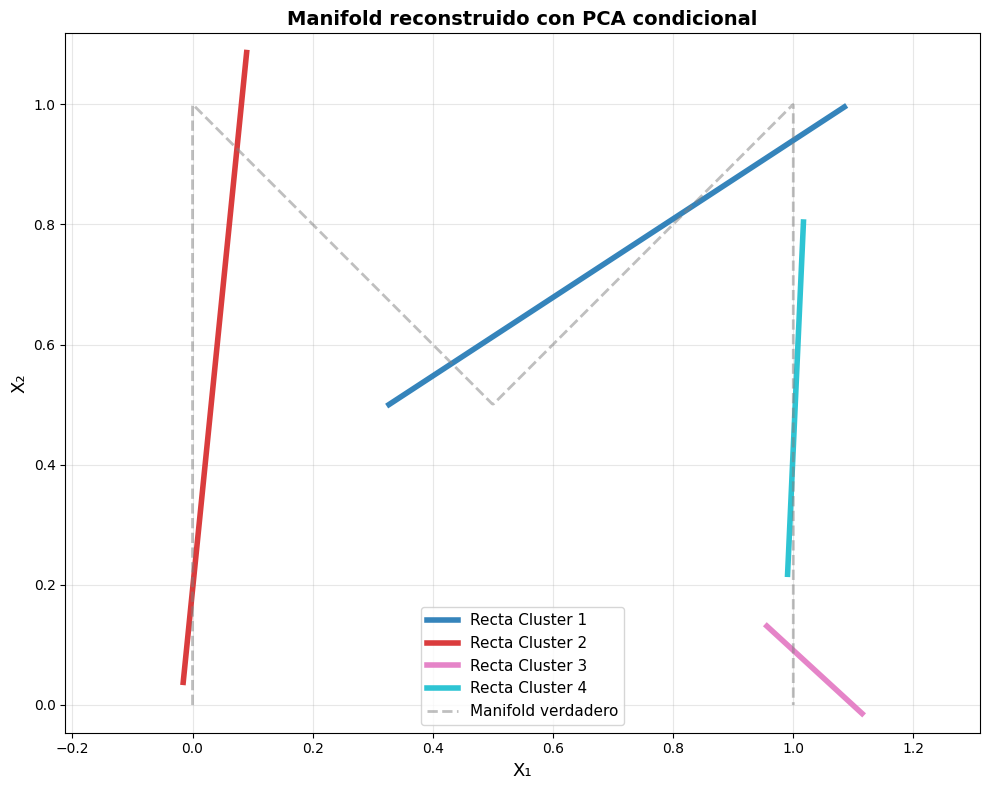

In [10]:
# Crear figura
fig, ax = plt.subplots(1, 1, figsize=(10, 8))

# Colores para cada cluster
colors = plt.cm.tab10(np.linspace(0, 1, K))

# Para cada cluster, reconstruir la recta
for k in range(K):
    # Datos del cluster
    cluster_points = X[em.labels_ == k]

    # Proyectar
    projections = pca_models[k].transform(cluster_points, k=1)

    # Valores extremos
    proj_min = np.min(projections)
    proj_max = np.max(projections)

    # Crear puntos uniformemente espaciados entre min y max
    latent_points = np.linspace(proj_min, proj_max, 100).reshape(-1, 1)

    # Reconstruir usando inverse_transform
    reconstructed = pca_models[k].inverse_transform(latent_points)

    # Graficar la recta
    ax.plot(reconstructed[:, 0], reconstructed[:, 1],
           c=colors[k], linewidth=4, alpha=0.9,
           label=f'Recta Cluster {k+1}')

# Graficar manifold verdadero
ax.plot(manifold_points[:, 0], manifold_points[:, 1],
       'gray', linewidth=2, alpha=0.5, linestyle='--',
       label='Manifold verdadero')

ax.set_xlabel('X₁', fontsize=13)
ax.set_ylabel('X₂', fontsize=13)
ax.set_title('Manifold reconstruido con PCA condicional',
            fontsize=14, fontweight='bold')
ax.legend(loc='best', fontsize=11)
ax.grid(True, alpha=0.3)
ax.axis('equal')
plt.tight_layout()
plt.show()



## Detector de Anomalías

 La detección de anomalías es una tarea crucial en muchos campos, donde el objetivo es identificar puntos de datos que se desvían significativamente del comportamiento esperado.



### Detector de anomalías: Grilla y clasificación por error cuadrático

 Una técnica común para la detección de anomalías, especialmente en contextos de reducción de dimensionalidad, es utilizar el error de reconstrucción de PCA.
 PCA busca las direcciones de mayor varianza en los datos (las componentes principales). Cuando un punto de datos se proyecta sobre un subespacio de menor dimensionalidad definido por estas componentes principales y luego se reconstruye de vuelta al espacio original, la reconstrucción será muy cercana al punto original si el punto se encuentra "cerca" del subespacio principal
Si un punto de datos es una anomalía, es probable que no se ajuste bien al modelo lineal capturado por las componentes principales. Por lo tanto, cuando se proyecta y reconstruye, la distancia entre el punto original y su reconstrucción (el error de reconstrucción) será significativamente mayor que para los puntos "normales". Este error de reconstrucción actúa como una medida de cuán "anómalo" es un punto. Se establece un umbral sobre el error de reconstrucción. Cualquier punto cuyo error de reconstrucción supere este umbral se clasifica como una anomalía.



In [11]:
# Definir grilla de puntos en [0, 1] × [0, 1]
grid_size = 100
x1_grid = np.linspace(0, 1, grid_size)
x2_grid = np.linspace(0, 1, grid_size)
X1_mesh, X2_mesh = np.meshgrid(x1_grid, x2_grid)
grid_points = np.c_[X1_mesh.ravel(), X2_mesh.ravel()]

# Umbral de error cuadrático
threshold = 0.01

# Clasificar cada punto de la grilla
is_anomaly = np.zeros(len(grid_points), dtype=bool)
errors = np.zeros(len(grid_points))

for i in range(len(grid_points)):
    point = grid_points[i]

    # Asignar a un cluster usando EM
    cluster = em.predict(point.reshape(1, -1))[0]

    # Proyectar usando el PCA del cluster
    projection = pca_models[cluster].transform(point.reshape(1, -1), k=1)

    # Reconstruir
    reconstruction = pca_models[cluster].inverse_transform(projection)

    # Calcular error cuadrático
    error = np.sum((point - reconstruction[0])**2)
    errors[i] = error

    # Clasificar como anomalía si supera umbral
    if error > threshold:
        is_anomaly[i] = True

# Estadísticas
n_normal = np.sum(~is_anomaly)
n_anomaly = np.sum(is_anomaly)


### Representación del Manifold mediante Puntos Normales

En el contexto de la detección de anomalías utilizando el error de reconstrucción de PCA, la visualización de los puntos clasificados como "normales" dentro de una grilla es una forma efectiva de inferir la forma del manifold que los algoritmos de clustering y reducción de dimensionalidad están modelando.
Se genera una grilla densa de puntos que cubre el espacio de interés (en este caso, $[0, 1] \times [0, 1]$). Para cada punto de la grilla, se determina a qué clúster pertenece (usando EM). Luego, se calcula el error de reconstrucción de ese punto utilizando el modelo PCA específico de ese clúster. Si el error de reconstrucción está por debajo de un umbral predefinido, el punto se considera "normal" y se asume que pertenece a la estructura del manifold. Si el error supera el umbral, se considera una "anomalía". Al graficar únicamente los puntos clasificados como normales, se revela la forma del manifold que los modelos (EM + PCA por clúster) han aprendido. Las regiones donde se concentran los puntos normales son aquellas donde el error de reconstrucción es bajo, lo que significa que el modelo puede representar bien esos puntos. Esto efectivamente "dibuja" el manifold en el espacio de características.


Una grilla más densa (`grid_size` mayor) permite una representación más fina del manifold. Un umbral más pequeño resultará en una representación más "delgada" y estricta del manifold, mientras que un umbral más grande permitirá una representación más "gruesa" que incluye puntos ligeramente más alejados de la estructura central.


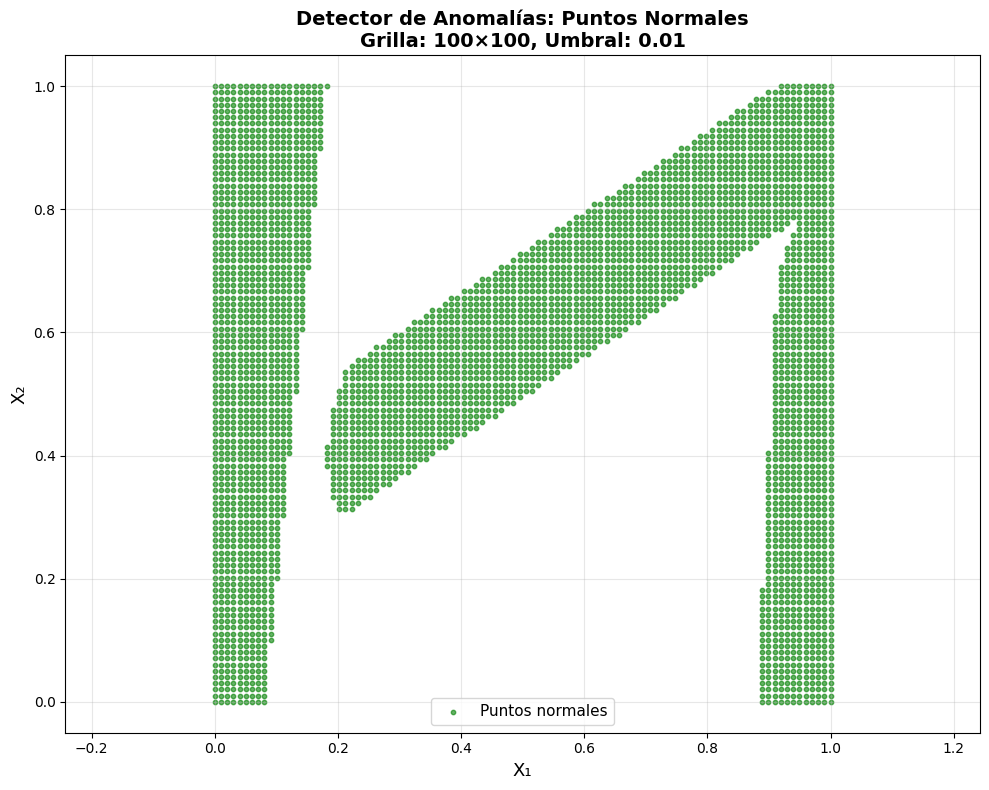

In [12]:

for i in range(len(grid_points)):
    point = grid_points[i]
    cluster = em.predict(point.reshape(1, -1))[0]
    projection = pca_models[cluster].transform(point.reshape(1, -1), k=1)
    reconstruction = pca_models[cluster].inverse_transform(projection)
    error = np.sum((point - reconstruction[0])**2)

    if error > threshold:
        is_anomaly[i] = True

# Extraer puntos normales
normal_points = grid_points[~is_anomaly]

# Generar manifold verdadero
u_manifold = np.linspace(0, 1, 1000)
manifold_points = g(u_manifold)

# Graficar
fig, ax = plt.subplots(1, 1, figsize=(10, 8))

# Puntos no anómalos
ax.scatter(normal_points[:, 0], normal_points[:, 1],
          c='green', s=10, alpha=0.6, label='Puntos normales')

ax.set_xlabel('X₁', fontsize=13)
ax.set_ylabel('X₂', fontsize=13)
ax.set_title(f'Detector de Anomalías: Puntos Normales\n' +
            f'Grilla: {grid_size}×{grid_size}, Umbral: {threshold}',
            fontsize=14, fontweight='bold')
ax.legend(loc='best', fontsize=11)
ax.grid(True, alpha=0.3)
ax.axis('equal')
plt.tight_layout()
plt.show()




### Mejora del Detector de Anomalías con Rangos de Proyección

 Un punto de dato puede tener un error de reconstrucción bajo si se encuentra cerca de la recta principal de un clúster, incluso si se proyecta fuera del rango de valores que realmente se observaron para ese clúster durante el entrenamiento. Es decir, un punto podría estar "en la dirección correcta" pero demasiado "lejos" en esa dirección.

Para refinar el detector de anomalías, se introduce un criterio adicional: verificar si la proyección de un punto de la grilla sobre la primera componente principal de su clúster cae dentro del rango de proyecciones observadas para los puntos de entrenamiento de ese clúster.

Si el error cuadrático entre el punto original y su reconstrucción es mayor que un umbral (`threshold`), el punto es una anomalía. Este criterio captura la desviación perpendicular a la recta principal del clúster. Si la proyección del punto sobre la primera componente principal cae fuera del rango (mínimo y máximo) de las proyecciones de los puntos de entrenamiento de ese clúster, el punto también es una anomalía. Este criterio captura la desviación a lo largo de la recta principal del clúster.


Un punto se considera "normal" solo si cumple *ambas* condiciones: su error de reconstrucción está por debajo del umbral *Y* su proyección cae dentro del rango observado para su clúster. Esta combinación permite definir el "manifold" de manera más estricta y precisa, excluyendo puntos que, aunque tengan un bajo error de reconstrucción, se encuentran en extensiones "no naturales" de la estructura del clúster.


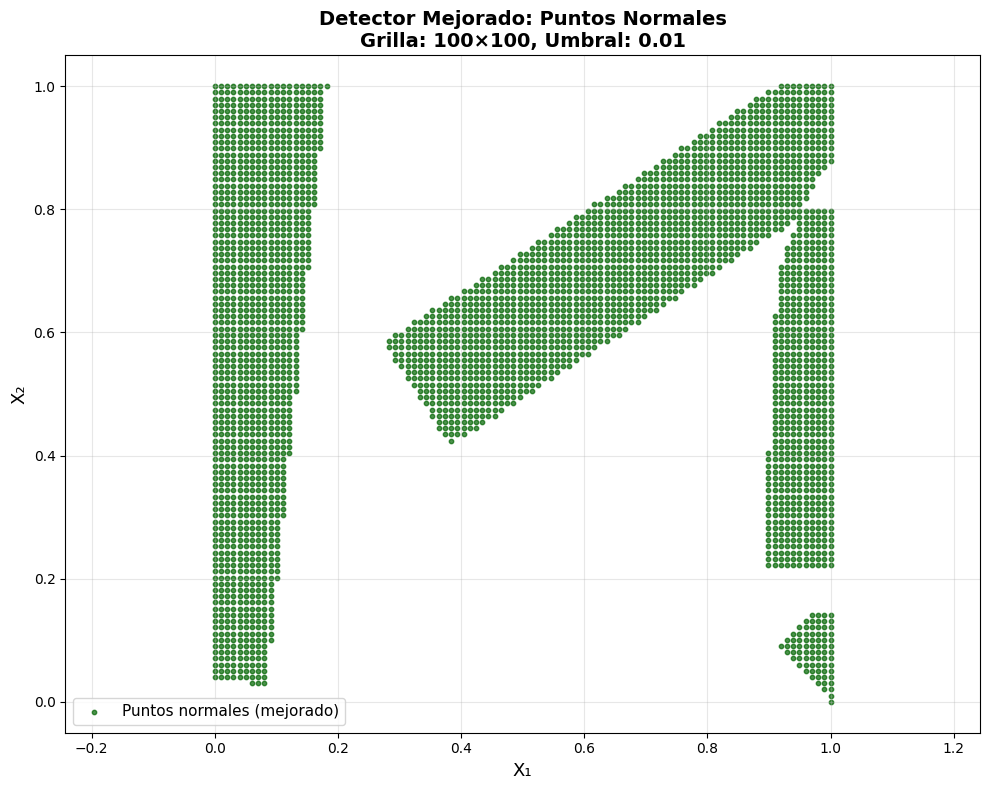

In [13]:

# Calcular valores extremos de proyección por cluster
proj_ranges = {}
for k in range(K):
    cluster_points = X[em.labels_ == k]
    projections = pca_models[k].transform(cluster_points, k=1)
    proj_ranges[k] = (np.min(projections), np.max(projections))

# Clasificar puntos (MEJORADO)
is_anomaly_improved = np.zeros(len(grid_points), dtype=bool)

for i in range(len(grid_points)):
    point = grid_points[i]
    cluster = em.predict(point.reshape(1, -1))[0]
    projection = pca_models[cluster].transform(point.reshape(1, -1), k=1)
    reconstruction = pca_models[cluster].inverse_transform(projection)

    # Error de reconstrucción
    error = np.sum((point - reconstruction[0])**2)

    # Verificar si está fuera del rango válido
    proj_min, proj_max = proj_ranges[cluster]
    out_of_range = (projection[0, 0] < proj_min) or (projection[0, 0] > proj_max)

    # Clasificar como anomalía si:
    # - Error > umbral, O
    # - Proyección fuera del rango
    if error > threshold or out_of_range:
        is_anomaly_improved[i] = True

# Extraer puntos normales
normal_points_improved = grid_points[~is_anomaly_improved]

# Graficar
fig, ax = plt.subplots(1, 1, figsize=(10, 8))

# Puntos no anómalos (mejorado)
ax.scatter(normal_points_improved[:, 0], normal_points_improved[:, 1],
          c='darkgreen', s=10, alpha=0.7, label='Puntos normales (mejorado)')

ax.set_xlabel('X₁', fontsize=13)
ax.set_ylabel('X₂', fontsize=13)
ax.set_title(f'Detector Mejorado: Puntos Normales\n' +
            f'Grilla: {grid_size}×{grid_size}, Umbral: {threshold}',
            fontsize=14, fontweight='bold')
ax.legend(loc='best', fontsize=11)
ax.grid(True, alpha=0.3)
ax.axis('equal')
plt.tight_layout()
plt.show()

